DATASET OVERVIEW
Shape: (212, 144)
Unique patients: 106
Rows per patient: {2: 106}
Missing values: 4

Target (Delta_12) distribution:
Delta_12
-5     1
-4     2
-3     8
-2     7
-1    10
 0    73
 1    19
 2    28
 3    35
 4     8
 5    21
Name: count, dtype: int64

Severity Score range: 0 – 5

Number of features (without Severity Score): 141

3-Class label distribution:
  Progression (class 0): 28 samples (13.2%)
  Stable (class 1): 73 samples (34.4%)
  Improvement (class 2): 111 samples (52.4%)


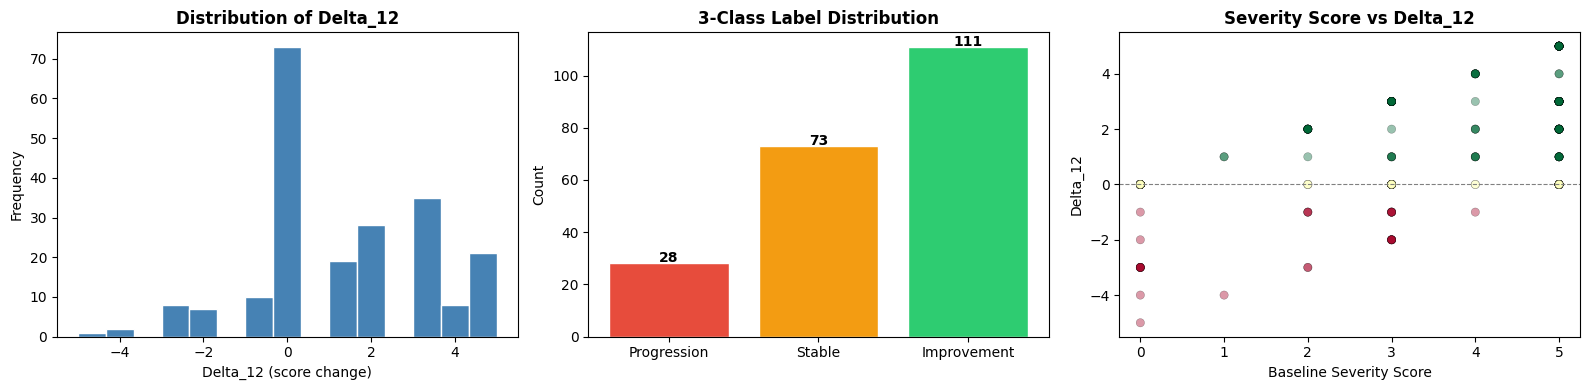

[Saved] fig1_data_overview.png

MISSING VALUES PER FEATURE (top 5)
NeutroRegionENorm_CALC             1
EosinoRegionENorm_CALC             1
RegionFRegionENorm_CALC            1
PlasmaLymphConnRegionENorm_CALC    1
dtype: int64

CROSS-VALIDATION: StratifiedGroupKFold (5-fold)
(All rows of the same patient remain in the same fold)

TASK 1a — ALL FEATURES: Model Comparison (5-fold CV)
  Random Forest              Acc=0.633±0.089  BalAcc=0.485±0.077  F1=0.484±0.096
  Gradient Boosting          Acc=0.599±0.055  BalAcc=0.479±0.054  F1=0.483±0.067
  SVM (RBF)                  Acc=0.501±0.098  BalAcc=0.429±0.099  F1=0.412±0.096
  Logistic Regression        Acc=0.472±0.110  BalAcc=0.418±0.095  F1=0.393±0.086
  KNN                        Acc=0.539±0.102  BalAcc=0.424±0.103  F1=0.409±0.104

  >>> Best model (all features): Random Forest

TASK 1b — CONFUSION MATRIX: Random Forest (all features)
              precision    recall  f1-score   support

 Progression       0.30      0.11      0.16     

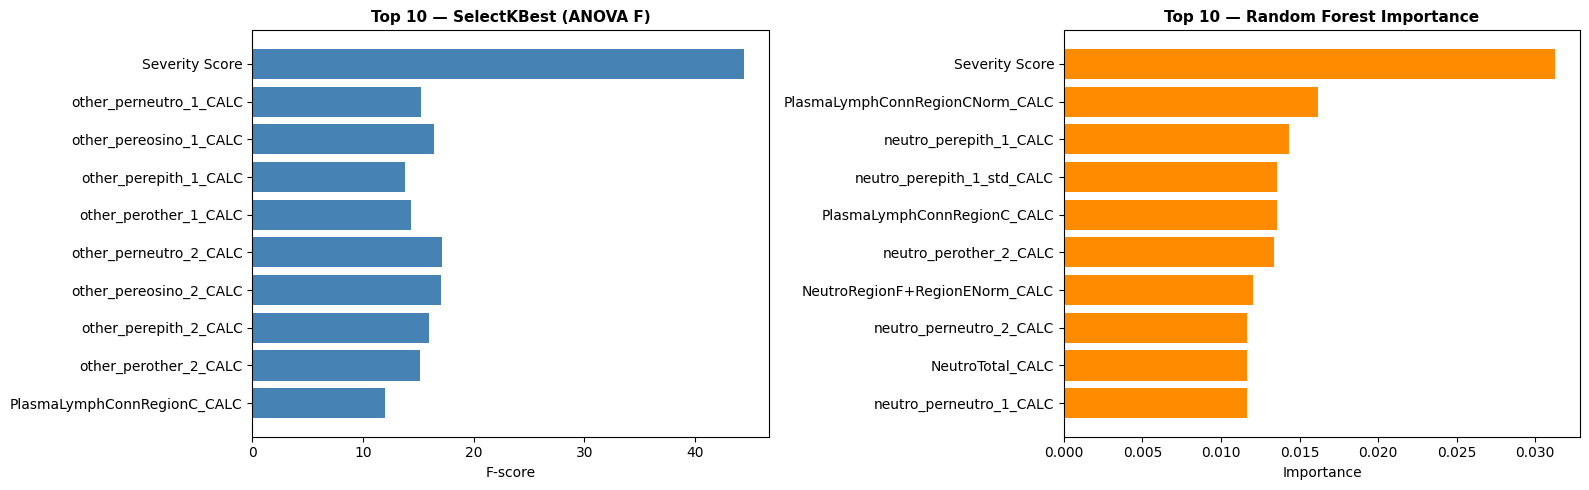

[Saved] fig2_feature_importance.png

  Final selected 10 features (RF-based):
  [np.str_('Severity Score'), np.str_('PlasmaLymphConnRegionCNorm_CALC'), np.str_('neutro_perepith_1_CALC'), np.str_('neutro_perepith_1_std_CALC'), np.str_('PlasmaLymphConnRegionC_CALC'), np.str_('neutro_perother_2_CALC'), np.str_('NeutroRegionF+RegionENorm_CALC'), np.str_('neutro_perneutro_2_CALC'), np.str_('NeutroTotal_CALC'), np.str_('neutro_perneutro_1_CALC')]

TASK 2a — AT MOST 10 FEATURES: Model Comparison (5-fold CV)
  Random Forest              Acc=0.589±0.076  BalAcc=0.464±0.058  F1=0.466±0.070
  Gradient Boosting          Acc=0.557±0.054  BalAcc=0.431±0.063  F1=0.422±0.072
  SVM (RBF)                  Acc=0.500±0.062  BalAcc=0.537±0.044  F1=0.379±0.031
  Logistic Regression        Acc=0.524±0.050  BalAcc=0.515±0.073  F1=0.459±0.047
  KNN                        Acc=0.599±0.086  BalAcc=0.503±0.079  F1=0.507±0.085

  >>> Best model (10 features): SVM (RBF)

TASK 2b — CONFUSION MATRIX: SVM (RBF) (10 fea

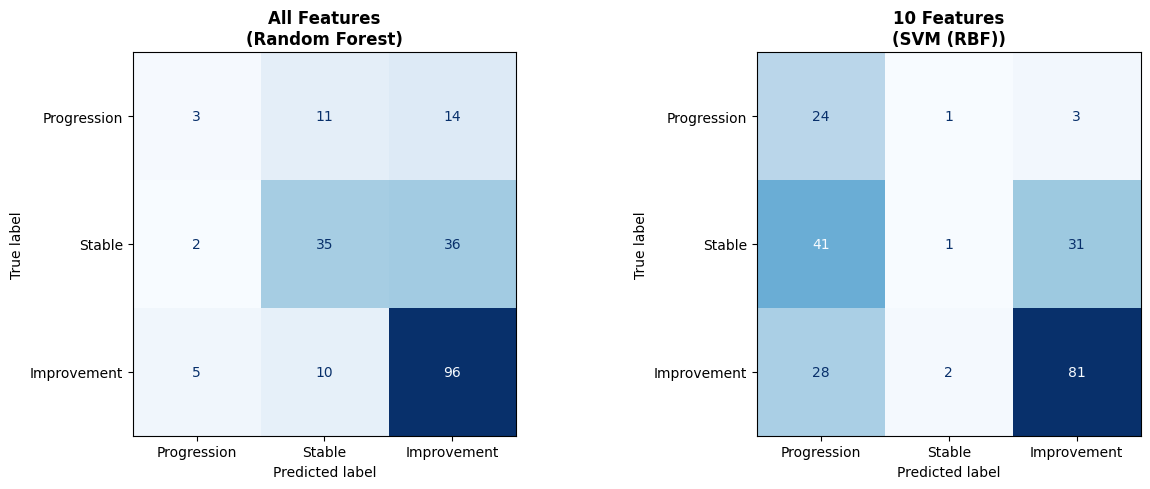

[Saved] fig3_confusion_matrices.png

PERFORMANCE SUMMARY

  ALL FEATURES:
  Model                     Acc (mean±std)         BalAcc (mean±std)      F1-macro (mean±std)
  Random Forest             0.633±0.089         0.485±0.077          0.484±0.096 ◄ BEST
  Gradient Boosting         0.599±0.055         0.479±0.054          0.483±0.067
  SVM (RBF)                 0.501±0.098         0.429±0.099          0.412±0.096
  Logistic Regression       0.472±0.110         0.418±0.095          0.393±0.086
  KNN                       0.539±0.102         0.424±0.103          0.409±0.104

  10 FEATURES (selected by Random Forest importance):
  Model                     Acc (mean±std)         BalAcc (mean±std)      F1-macro (mean±std)
  Random Forest             0.589±0.076         0.464±0.058          0.466±0.070
  Gradient Boosting         0.557±0.054         0.431±0.063          0.422±0.072
  SVM (RBF)                 0.500±0.062         0.537±0.044          0.379±0.031 ◄ BEST
  Logistic Regression

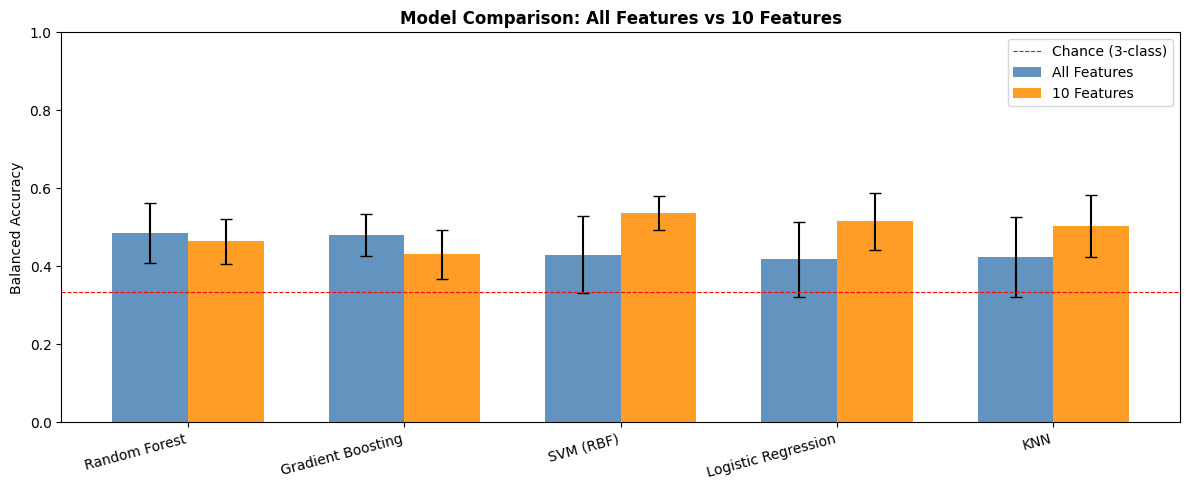

[Saved] fig4_model_comparison.png


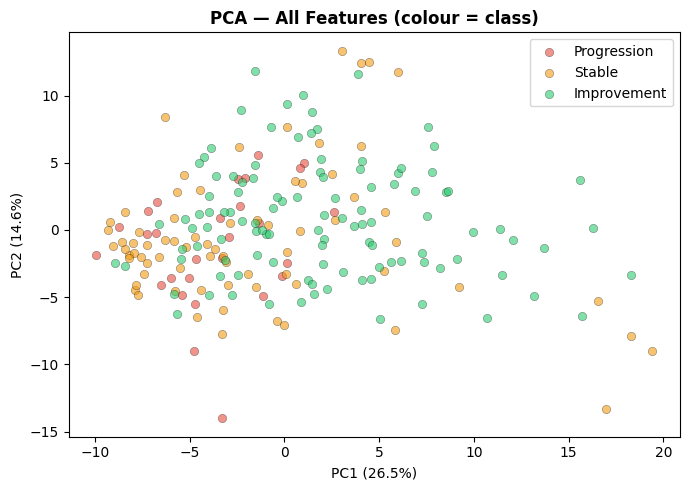

[Saved] fig5_pca.png


In [2]:
# ============================================================
# CSI-7-MAL Resit Coursework — Full ML Pipeline
# ============================================================

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedGroupKFold, cross_val_predict, cross_validate
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.feature_selection import SelectKBest, f_classif, RFE
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, f1_score, balanced_accuracy_score, mean_absolute_error
)
from sklearn.decomposition import PCA
from scipy.stats import spearmanr

# ─── 1. LOAD & INSPECT ───────────────────────────────────────────────────────
df = pd.read_excel('/content/ML_Dataset.xlsx')
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Shape: {df.shape}")
print(f"Unique patients: {df['PatID'].nunique()}")
print(f"Rows per patient: {df.groupby('PatID').size().value_counts().to_dict()}")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"\nTarget (Delta_12) distribution:")
print(df['Delta_12'].value_counts().sort_index())
print(f"\nSeverity Score range: {df['Severity Score'].min()} – {df['Severity Score'].max()}")

# ─── 2. PREPROCESSING ────────────────────────────────────────────────────────
# Feature columns (exclude PatID, Severity Score, Delta_12)
feature_cols = [c for c in df.columns if c not in ['PatID', 'Severity Score', 'Delta_12']]
print(f"\nNumber of features (without Severity Score): {len(feature_cols)}")

# Also create feature set including Severity Score
feature_cols_with_score = ['Severity Score'] + feature_cols

X_all = df[feature_cols_with_score].values
y_raw = df['Delta_12'].values
groups = df['PatID'].values  # group labels for GroupKFold

# ─── 3. TARGET ENCODING ──────────────────────────────────────────────────────
def encode_class(delta):
    """Encode Delta into 3-class label."""
    if delta < 0:
        return 0  # Progression (worsening)
    elif delta == 0:
        return 1  # Stable
    else:
        return 2  # Improvement

y_class = np.array([encode_class(d) for d in y_raw])
class_names = ['Progression', 'Stable', 'Improvement']

print("\n3-Class label distribution:")
unique, counts = np.unique(y_class, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {class_names[u]} (class {u}): {c} samples ({100*c/len(y_class):.1f}%)")

# ─── 4. DATA VISUALISATION ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 4a. Delta distribution
axes[0].hist(y_raw, bins=15, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Delta_12', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Delta_12 (score change)')
axes[0].set_ylabel('Frequency')

# 4b. 3-class bar chart
class_counts = [np.sum(y_class == i) for i in range(3)]
bar_colors = ['#e74c3c', '#f39c12', '#2ecc71']
bars = axes[1].bar(class_names, class_counts, color=bar_colors, edgecolor='white')
axes[1].set_title('3-Class Label Distribution', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Count')
for bar, count in zip(bars, class_counts):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 str(count), ha='center', fontweight='bold')

# 4c. Severity Score vs Delta
axes[2].scatter(df['Severity Score'], y_raw, alpha=0.4, c=y_class,
                cmap='RdYlGn', edgecolors='k', linewidths=0.3)
axes[2].set_title('Severity Score vs Delta_12', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Baseline Severity Score')
axes[2].set_ylabel('Delta_12')
axes[2].axhline(0, color='gray', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.savefig('fig1_data_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("[Saved] fig1_data_overview.png")

# ─── 5. MISSING VALUE & CORRELATION ANALYSIS ─────────────────────────────────
print("\n" + "=" * 60)
print("MISSING VALUES PER FEATURE (top 5)")
print("=" * 60)
miss = df[feature_cols_with_score].isnull().sum()
print(miss[miss > 0])

# ─── 6. CROSS-VALIDATION SETUP ───────────────────────────────────────────────
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
print("\n" + "=" * 60)
print("CROSS-VALIDATION: StratifiedGroupKFold (5-fold)")
print("(All rows of the same patient remain in the same fold)")
print("=" * 60)

# ─── 7. PIPELINE BUILDER ─────────────────────────────────────────────────────
def make_pipe(clf):
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('clf', clf)
    ])

# ─── 8. FULL FEATURE SET — MODEL COMPARISON ───────────────────────────────────
print("\n" + "=" * 60)
print("TASK 1a — ALL FEATURES: Model Comparison (5-fold CV)")
print("=" * 60)

models = {
    'Random Forest':     RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced'),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM (RBF)':         SVC(kernel='rbf', class_weight='balanced', random_state=42, probability=True),
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'KNN':               KNeighborsClassifier(n_neighbors=7),
}

results_all = {}
for name, clf in models.items():
    pipe = make_pipe(clf)
    cv_results = cross_validate(
        pipe, X_all, y_class, groups=groups, cv=cv,
        scoring=['accuracy', 'balanced_accuracy', 'f1_macro'],
        return_train_score=False
    )
    acc_scores = cv_results['test_accuracy']
    bal_scores = cv_results['test_balanced_accuracy']
    f1_scores  = cv_results['test_f1_macro']
    results_all[name] = {
        'acc_mean': acc_scores.mean(), 'acc_std': acc_scores.std(),
        'bal_mean': bal_scores.mean(), 'bal_std': bal_scores.std(),
        'f1_mean':  f1_scores.mean(),  'f1_std':  f1_scores.std(),
    }
    print(f"  {name:25s}  Acc={acc_scores.mean():.3f}±{acc_scores.std():.3f}  "
          f"BalAcc={bal_scores.mean():.3f}±{bal_scores.std():.3f}  "
          f"F1={f1_scores.mean():.3f}±{f1_scores.std():.3f}")

# Best model (by balanced accuracy)
best_name = max(results_all, key=lambda k: results_all[k]['bal_mean'])
print(f"\n  >>> Best model (all features): {best_name}")

# ─── 9. TASK 1b — CONFUSION MATRIX (best model, all features) ────────────────
print("\n" + "=" * 60)
print(f"TASK 1b — CONFUSION MATRIX: {best_name} (all features)")
print("=" * 60)

best_clf_all = make_pipe(models[best_name])
y_pred_all = cross_val_predict(best_clf_all, X_all, y_class, groups=groups, cv=cv)

print(classification_report(y_class, y_pred_all, target_names=class_names))
cm_all = confusion_matrix(y_class, y_pred_all)
print("Confusion Matrix (rows=true, cols=predicted):")
print(pd.DataFrame(cm_all, index=class_names, columns=class_names))

# MAE on regression scale (treating class as ordinal)
mae_all = mean_absolute_error(y_class, y_pred_all)
print(f"\nOrdinal MAE (all features): {mae_all:.3f}")

# ─── 10. FEATURE SELECTION ────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("FEATURE SELECTION — Top 10 Features")
print("=" * 60)

# Impute before selection
imputer = SimpleImputer(strategy='median')
scaler  = StandardScaler()
X_imp   = imputer.fit_transform(X_all)
X_scaled = scaler.fit_transform(X_imp)

# Method A: SelectKBest (ANOVA F-test)
selector_skb = SelectKBest(f_classif, k=10)
selector_skb.fit(X_scaled, y_class)
top10_skb_idx = selector_skb.get_support(indices=True)
top10_skb_names = np.array(feature_cols_with_score)[top10_skb_idx]
top10_skb_scores = selector_skb.scores_[top10_skb_idx]

print("\n  SelectKBest (ANOVA F-test) Top 10:")
for n, s in sorted(zip(top10_skb_names, top10_skb_scores), key=lambda x: -x[1]):
    print(f"    {n:45s}  F={s:.2f}")

# Method B: RF feature importance
rf_fs = RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced')
rf_fs.fit(X_scaled, y_class)
importances = rf_fs.feature_importances_
top10_rf_idx = np.argsort(importances)[::-1][:10]
top10_rf_names = np.array(feature_cols_with_score)[top10_rf_idx]

print("\n  Random Forest Importance Top 10:")
for n, imp in zip(top10_rf_names, importances[top10_rf_idx]):
    print(f"    {n:45s}  importance={imp:.4f}")

# --- Feature importance bar chart ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# SKB
axes[0].barh(top10_skb_names[::-1], top10_skb_scores[::-1], color='steelblue')
axes[0].set_title('Top 10 — SelectKBest (ANOVA F)', fontsize=11, fontweight='bold')
axes[0].set_xlabel('F-score')

# RF
axes[1].barh(top10_rf_names[::-1], importances[top10_rf_idx][::-1], color='darkorange')
axes[1].set_title('Top 10 — Random Forest Importance', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.savefig('fig2_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("[Saved] fig2_feature_importance.png")

# Choose union / overlap for final 10 features
# Use RF top-10 as primary (ensemble methods capture non-linear importance)
final_10_features = list(top10_rf_names)
print(f"\n  Final selected 10 features (RF-based):\n  {final_10_features}")

X_10 = X_scaled[:, top10_rf_idx]

# ─── 11. TASK 2a — ALL MODELS WITH 10 FEATURES ────────────────────────────────
print("\n" + "=" * 60)
print("TASK 2a — AT MOST 10 FEATURES: Model Comparison (5-fold CV)")
print("=" * 60)

results_10 = {}
for name, clf in models.items():
    pipe_10 = Pipeline([
        ('clf', clf.__class__(**clf.get_params()))
    ])
    cv_results = cross_validate(
        pipe_10, X_10, y_class, groups=groups, cv=cv,
        scoring=['accuracy', 'balanced_accuracy', 'f1_macro'],
        return_train_score=False
    )
    acc_scores = cv_results['test_accuracy']
    bal_scores = cv_results['test_balanced_accuracy']
    f1_scores  = cv_results['test_f1_macro']
    results_10[name] = {
        'acc_mean': acc_scores.mean(), 'acc_std': acc_scores.std(),
        'bal_mean': bal_scores.mean(), 'bal_std': bal_scores.std(),
        'f1_mean':  f1_scores.mean(),  'f1_std':  f1_scores.std(),
    }
    print(f"  {name:25s}  Acc={acc_scores.mean():.3f}±{acc_scores.std():.3f}  "
          f"BalAcc={bal_scores.mean():.3f}±{bal_scores.std():.3f}  "
          f"F1={f1_scores.mean():.3f}±{f1_scores.std():.3f}")

best_name_10 = max(results_10, key=lambda k: results_10[k]['bal_mean'])
print(f"\n  >>> Best model (10 features): {best_name_10}")

# ─── 12. TASK 2b — CONFUSION MATRIX (best model, 10 features) ────────────────
print("\n" + "=" * 60)
print(f"TASK 2b — CONFUSION MATRIX: {best_name_10} (10 features)")
print("=" * 60)

best_clf_10 = Pipeline([('clf', models[best_name_10].__class__(**models[best_name_10].get_params()))])
y_pred_10 = cross_val_predict(best_clf_10, X_10, y_class, groups=groups, cv=cv)

print(classification_report(y_class, y_pred_10, target_names=class_names))
cm_10 = confusion_matrix(y_class, y_pred_10)
print("Confusion Matrix (rows=true, cols=predicted):")
print(pd.DataFrame(cm_10, index=class_names, columns=class_names))

mae_10 = mean_absolute_error(y_class, y_pred_10)
print(f"\nOrdinal MAE (10 features): {mae_10:.3f}")

# ─── 13. CONFUSION MATRIX PLOTS ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, cm, title in [
    (axes[0], cm_all, f'All Features\n({best_name})'),
    (axes[1], cm_10,  f'10 Features\n({best_name_10})')
]:
    disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('fig3_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("[Saved] fig3_confusion_matrices.png")

# ─── 14. PERFORMANCE SUMMARY TABLE ───────────────────────────────────────────
print("\n" + "=" * 60)
print("PERFORMANCE SUMMARY")
print("=" * 60)

print("\n  ALL FEATURES:")
print(f"  {'Model':<25} {'Acc (mean±std)':<22} {'BalAcc (mean±std)':<22} {'F1-macro (mean±std)'}")
for name, r in results_all.items():
    marker = " ◄ BEST" if name == best_name else ""
    print(f"  {name:<25} {r['acc_mean']:.3f}±{r['acc_std']:.3f}         "
          f"{r['bal_mean']:.3f}±{r['bal_std']:.3f}          "
          f"{r['f1_mean']:.3f}±{r['f1_std']:.3f}{marker}")

print(f"\n  10 FEATURES (selected by Random Forest importance):")
print(f"  {'Model':<25} {'Acc (mean±std)':<22} {'BalAcc (mean±std)':<22} {'F1-macro (mean±std)'}")
for name, r in results_10.items():
    marker = " ◄ BEST" if name == best_name_10 else ""
    print(f"  {name:<25} {r['acc_mean']:.3f}±{r['acc_std']:.3f}         "
          f"{r['bal_mean']:.3f}±{r['bal_std']:.3f}          "
          f"{r['f1_mean']:.3f}±{r['f1_std']:.3f}{marker}")

# ─── 15. MODEL COMPARISON PLOT ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(models))
w = 0.35
bal_all_means = [results_all[n]['bal_mean'] for n in models]
bal_all_stds  = [results_all[n]['bal_std']  for n in models]
bal_10_means  = [results_10[n]['bal_mean']  for n in models]
bal_10_stds   = [results_10[n]['bal_std']   for n in models]

ax.bar(x - w/2, bal_all_means, w, yerr=bal_all_stds, label='All Features',
       color='steelblue', capsize=4, alpha=0.85)
ax.bar(x + w/2, bal_10_means,  w, yerr=bal_10_stds,  label='10 Features',
       color='darkorange', capsize=4, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(list(models.keys()), rotation=15, ha='right')
ax.set_ylabel('Balanced Accuracy')
ax.set_title('Model Comparison: All Features vs 10 Features', fontsize=12, fontweight='bold')
ax.legend()
ax.set_ylim(0, 1.0)
ax.axhline(0.333, color='red', linestyle='--', linewidth=0.8, label='Chance (3-class)')
ax.legend()
plt.tight_layout()
plt.savefig('fig4_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("[Saved] fig4_model_comparison.png")

# ─── 16. PCA VISUALISATION ───────────────────────────────────────────────────
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
fig, ax = plt.subplots(figsize=(7, 5))
colors = ['#e74c3c', '#f39c12', '#2ecc71']
for i, (cls, col) in enumerate(zip(class_names, colors)):
    mask = y_class == i
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], c=col, label=cls,
               alpha=0.6, edgecolors='k', linewidths=0.3)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('PCA — All Features (colour = class)', fontsize=12, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('fig5_pca.png', dpi=150, bbox_inches='tight')
plt.show()
print("[Saved] fig5_pca.png")
